<a href="https://colab.research.google.com/github/divyamjariwal/Deep-Learning-Lab/blob/main/Dl_lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment 7 : Sequence to Sequence Learning with Transformers

Enable GPU


In [1]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type=="cuda":
    print(torch.cuda.get_device_name(0))

Using device: cuda
Tesla T4


Install Libraries

In [2]:
!pip -q install sacrebleu spacy matplotlib
!python -m spacy download en_core_web_sm
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 123.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 113.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


Upload Dataset

In [3]:
from google.colab import files
uploaded = files.upload()

Saving spa.txt to spa (2).txt


In [4]:
!ls

 sample_data  'spa (1).txt'  'spa (2).txt'   spa.txt


Read Dataset & Split

In [5]:
import random

pairs=[]
with open("spa.txt",encoding="utf-8") as f:
    for line in f:
        eng,spa=line.strip().split("\t")
        pairs.append((eng.lower(),spa.lower()))

random.shuffle(pairs)

n=len(pairs)
train=pairs[:int(0.8*n)]
val=pairs[int(0.8*n):int(0.9*n)]
test=pairs[int(0.9*n):]

# FAST MODE (important for 30 min training)
train=train[:7000]
val=val[:1000]
test=test[:500]

print("Train:",len(train))
print("Val:",len(val))
print("Test:",len(test))

Train: 7000
Val: 1000
Test: 500


Dataset Information (EDA)

In [6]:
for i in range(5):
    print("\nEnglish:",train[i][0])
    print("Spanish:",train[i][1])


English: i was dizzy.
Spanish: estaba mareada.

English: tom doesn't know what he's doing.
Spanish: tom no sabe lo que está haciendo.

English: where did you take your shoes off?
Spanish: ¿dónde te quitaste los zapatos?

English: let's turn off the tv.
Spanish: apaguemos la televisión.

English: this is no joke.
Spanish: esto no es ninguna broma.


Tokenizers

In [7]:
import spacy
spacy_en=spacy.load("en_core_web_sm")
spacy_es=spacy.load("es_core_news_sm")

def tok_en(text):
    return [t.text for t in spacy_en.tokenizer(text)]

def tok_es(text):
    return [t.text for t in spacy_es.tokenizer(text)]

Sentence Length Analysis

In [8]:
src_lengths=[len(tok_en(s[0])) for s in train]
trg_lengths=[len(tok_es(s[1])) for s in train]

print("Max English length:",max(src_lengths))
print("Max Spanish length:",max(trg_lengths))
print("Avg English:",sum(src_lengths)/len(src_lengths))
print("Avg Spanish:",sum(trg_lengths)/len(trg_lengths))

Max English length: 46
Max Spanish length: 44
Avg English: 7.690857142857143
Avg Spanish: 7.3108571428571425


Visualization

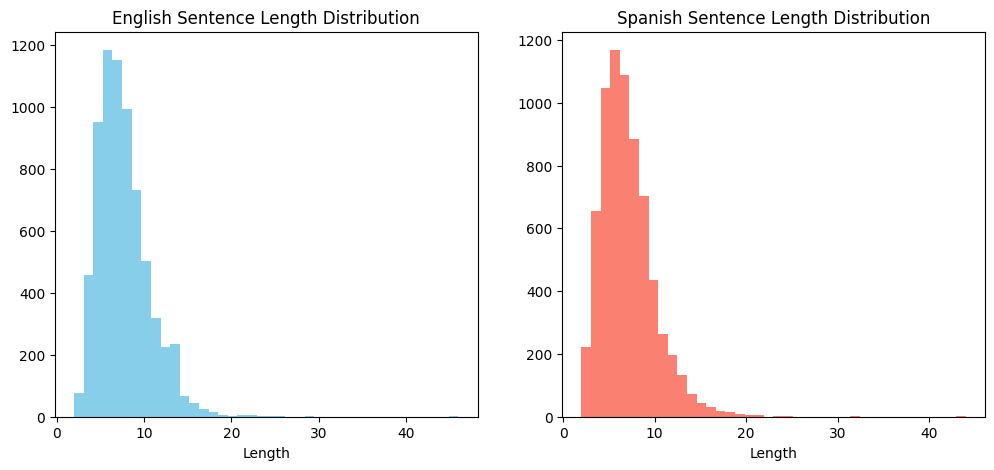

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(src_lengths,bins=40,color="skyblue")
plt.title("English Sentence Length Distribution")
plt.xlabel("Length")

plt.subplot(1,2,2)
plt.hist(trg_lengths,bins=40,color="salmon")
plt.title("Spanish Sentence Length Distribution")
plt.xlabel("Length")

plt.show()

Vocabulary

In [10]:
from collections import Counter

def build_vocab(data,tokenizer):
    counter=Counter()
    for s,t in data:
        tokens=tokenizer(s if tokenizer==tok_en else t)
        counter.update(tokens)

    vocab={"<pad>":0,"<sos>":1,"<eos>":2,"<unk>":3}

    for w,f in counter.items():
        if f>=2:
            vocab[w]=len(vocab)

    return vocab

SRC_vocab=build_vocab(train,tok_en)
TRG_vocab=build_vocab(train,tok_es)

PAD_IDX=SRC_vocab["<pad>"]
SOS_IDX=SRC_vocab["<sos>"]
EOS_IDX=SRC_vocab["<eos>"]

print("English vocab:",len(SRC_vocab))
print("Spanish vocab:",len(TRG_vocab))

English vocab: 2118
Spanish vocab: 2699


Most Common Words Visualization

In [11]:
from collections import Counter

eng_words=Counter()
spa_words=Counter()

for e,s in train:
    eng_words.update(tok_en(e))
    spa_words.update(tok_es(s))

print("Top English words:",eng_words.most_common(10))
print("Top Spanish words:",spa_words.most_common(10))

Top English words: [('.', 6059), ('i', 1972), ('the', 1653), ('to', 1519), ('you', 1430), ('tom', 1178), ('a', 1077), ('?', 965), ('is', 899), ("n't", 872)]
Top Spanish words: [('.', 6045), ('de', 1398), ('que', 1245), ('no', 1227), ('a', 1186), ('tom', 1112), ('la', 1028), ('¿', 968), ('?', 968), ('el', 879)]


Numericalization

In [12]:
import torch

def numericalize(pair):
    src,trg=pair
    src=["<sos>"]+tok_en(src)+["<eos>"]
    trg=["<sos>"]+tok_es(trg)+["<eos>"]

    src_ids=[SRC_vocab.get(x,3) for x in src]
    trg_ids=[TRG_vocab.get(x,3) for x in trg]

    return torch.tensor(src_ids),torch.tensor(trg_ids)

Masks

In [13]:
def make_src_mask(src):
    return (src!=PAD_IDX).unsqueeze(1).unsqueeze(2)

def make_trg_mask(trg):
    L=trg.shape[1]
    pad_mask=(trg!=PAD_IDX).unsqueeze(1).unsqueeze(2)
    sub_mask=torch.tril(torch.ones((L,L))).bool().to(device)
    return pad_mask & sub_mask

Positional Encoding

In [14]:
import math
import torch
import torch.nn as nn

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) *
                             (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        # IMPORTANT: register buffer instead of .to(device)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

Transformer Model

In [15]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_model):
        super().__init__()
        self.q=nn.Linear(d_model,d_model)
        self.k=nn.Linear(d_model,d_model)
        self.v=nn.Linear(d_model,d_model)
        self.fc=nn.Linear(d_model,d_model)
        self.scale=math.sqrt(d_model)

    def forward(self,q,k,v,mask=None):
        Q=self.q(q)
        K=self.k(k)
        V=self.v(v)
        energy=torch.matmul(Q,K.transpose(-2,-1))/self.scale
        if mask is not None:
            energy=energy.masked_fill(mask==0,-1e10)
        attn=torch.softmax(energy,dim=-1)
        out=torch.matmul(attn,V)
        return self.fc(out)

In [16]:
class EncoderLayer(nn.Module):
    def __init__(self,d_model):
        super().__init__()
        self.attn=MultiHeadAttention(d_model)
        self.norm1=nn.LayerNorm(d_model)
        self.ff=nn.Sequential(nn.Linear(d_model,4*d_model),nn.ReLU(),nn.Linear(4*d_model,d_model))
        self.norm2=nn.LayerNorm(d_model)

    def forward(self,x,mask):
        x=self.norm1(x+self.attn(x,x,x,mask))
        x=self.norm2(x+self.ff(x))
        return x

class DecoderLayer(nn.Module):
    def __init__(self,d_model):
        super().__init__()
        self.self_attn=MultiHeadAttention(d_model)
        self.cross_attn=MultiHeadAttention(d_model)
        self.norm1=nn.LayerNorm(d_model)
        self.norm2=nn.LayerNorm(d_model)
        self.ff=nn.Sequential(nn.Linear(d_model,4*d_model),nn.ReLU(),nn.Linear(4*d_model,d_model))
        self.norm3=nn.LayerNorm(d_model)

    def forward(self,x,enc,src_mask,trg_mask):
        x=self.norm1(x+self.self_attn(x,x,x,trg_mask))
        x=self.norm2(x+self.cross_attn(x,enc,enc,src_mask))
        x=self.norm3(x+self.ff(x))
        return x

In [17]:
class Transformer(nn.Module):
    def __init__(self,src_vocab,trg_vocab,d_model=96,layers=2):
        super().__init__()
        self.src_emb=nn.Embedding(src_vocab,d_model)
        self.trg_emb=nn.Embedding(trg_vocab,d_model)
        self.pos=PositionalEncoding(d_model)

        self.enc=nn.ModuleList([EncoderLayer(d_model) for _ in range(layers)])
        self.dec=nn.ModuleList([DecoderLayer(d_model) for _ in range(layers)])
        self.fc=nn.Linear(d_model,trg_vocab)

    def forward(self,src,trg,src_mask,trg_mask):
        src=self.pos(self.src_emb(src))
        trg=self.pos(self.trg_emb(trg))
        for l in self.enc:
            src=l(src,src_mask)
        for l in self.dec:
            trg=l(trg,src,src_mask,trg_mask)
        return self.fc(trg)

Training

In [18]:
model=Transformer(len(SRC_vocab),len(TRG_vocab)).to(device)
optimizer=torch.optim.Adam(model.parameters(),lr=3e-4)
criterion=nn.CrossEntropyLoss(ignore_index=PAD_IDX)

EPOCHS=30

In [19]:
loss_history=[]

for epoch in range(EPOCHS):
    model.train()
    total_loss=0

    for pair in train:
        src,trg=numericalize(pair)
        src, trg = src.unsqueeze(0).to(device), trg.unsqueeze(0).to(device)

        trg_in=trg[:,:-1]
        trg_out=trg[:,1:]

        src_mask=make_src_mask(src)
        trg_mask=make_trg_mask(trg_in)

        out=model(src,trg_in,src_mask,trg_mask)
        out=out.reshape(-1,out.shape[-1])
        trg_out=trg_out.reshape(-1)

        loss=criterion(out,trg_out)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()

    avg_loss=total_loss/len(train)
    loss_history.append(avg_loss)
    print("Epoch",epoch+1,"Loss",avg_loss)

Epoch 1 Loss 4.010322579852172
Epoch 2 Loss 3.0195644661688377
Epoch 3 Loss 2.4756466619553312
Epoch 4 Loss 2.04284564798006
Epoch 5 Loss 1.7003580270931125
Epoch 6 Loss 1.4241547333395908
Epoch 7 Loss 1.2087207528513724
Epoch 8 Loss 1.0355066346437005
Epoch 9 Loss 0.9091221358846607
Epoch 10 Loss 0.8009635822043887
Epoch 11 Loss 0.7145757258325549
Epoch 12 Loss 0.6480394507786259
Epoch 13 Loss 0.5938377446516284
Epoch 14 Loss 0.5444411468688465
Epoch 15 Loss 0.5160527355752585
Epoch 16 Loss 0.4815089943312341
Epoch 17 Loss 0.45455855500494363
Epoch 18 Loss 0.43409592037923617
Epoch 19 Loss 0.4155575709082935
Epoch 20 Loss 0.3935247541853345
Epoch 21 Loss 0.38463413076191966
Epoch 22 Loss 0.36748627858805205
Epoch 23 Loss 0.3569168326312044
Epoch 24 Loss 0.35173765121645245
Epoch 25 Loss 0.33840109922248146
Epoch 26 Loss 0.3285153921733124
Epoch 27 Loss 0.31519671607867766
Epoch 28 Loss 0.3080856237611006
Epoch 29 Loss 0.3049060209274654
Epoch 30 Loss 0.29663230780794403


Training Loss Visualization

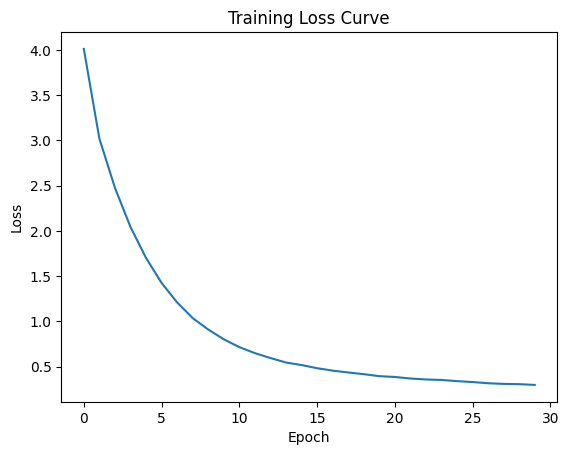

In [20]:
plt.plot(loss_history)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Translation Test

In [22]:
def translate(sentence, max_len=15):

    model.eval()

    # encode
    tokens = ["<sos>"] + tok_en(sentence.lower()) + ["<eos>"]
    src_ids = [SRC_vocab.get(t,3) for t in tokens]

    src = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    trg_ids = [SOS_IDX]

    for _ in range(max_len):

        trg_tensor = torch.tensor(trg_ids, dtype=torch.long).unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(src, trg_tensor, None, None)

        # ---- THIS IS THE IMPORTANT FIX ----
        last_word_logits = output[:, -1, :]        # (1, vocab_size)
        next_token = torch.argmax(last_word_logits, dim=1).item()

        trg_ids.append(next_token)

        if next_token == EOS_IDX and len(trg_ids) > 3:
            break

    # convert ids to words
    inv_vocab = {v:k for k,v in TRG_vocab.items()}
    words = [inv_vocab.get(i,"<unk>") for i in trg_ids[1:-1]]

    return " ".join(words)

In [23]:
print("hello ->", translate("hello"))
print("thanks ->", translate("thanks"))
print("i am fine ->", translate("i am fine"))
print("how are you ->", translate("how are you"))


hello -> <unk> .
thanks -> gracias <eos> volvió .
i am fine -> estoy bien de bien .
how are you -> ¿ es usted están eres sos .


BLEU Score

In [24]:
import sacrebleu

refs=[]
preds=[]

for e,s in test[:200]:
    preds.append(translate(e))
    refs.append([s])

print("BLEU Score:",sacrebleu.corpus_bleu(preds,refs).score)

BLEU Score: 33.9132609103075
